# ENTRENAMIENTO METAVIR-AI

## 1: Preprocesamiento de Imágenes



In [3]:
!pip install kaggle
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"marcosrivkyo","key":"931f7c50a4e3924d90c719bd2f894b9a"}'}

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
# ===================================
# Descarga y descompresión del dataset
# ===================================
!kaggle datasets download -d vibhingupta028/liver-histopathology-fibrosis-ultrasound-images
!unzip liver-histopathology-fibrosis-ultrasound-images.zip -d ./liver_dataset

Streaming output truncated to the last 5000 lines.
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7378.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a738.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7384.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7405.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a741.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7410.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7412.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7415.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7425.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7431.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7435.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7446.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7448.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7460.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a7464.jpg  
  inflating: ./liver_dataset/Dataset/Dataset/F0/a74

In [7]:
import os

for root, dirs, files in os.walk('./liver_dataset'):
    level = root.replace('./liver_dataset', '').count(os.sep)
    indent = ' ' * 4 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)


liver_dataset/
    Dataset/
        Dataset/
            F4/
            F3/
            F0/
            F1/
            F2/


Número total de imágenes: 6323

Número de imágenes por clase:
F0: 2114
F1: 861
F2: 793
F3: 857
F4: 1698


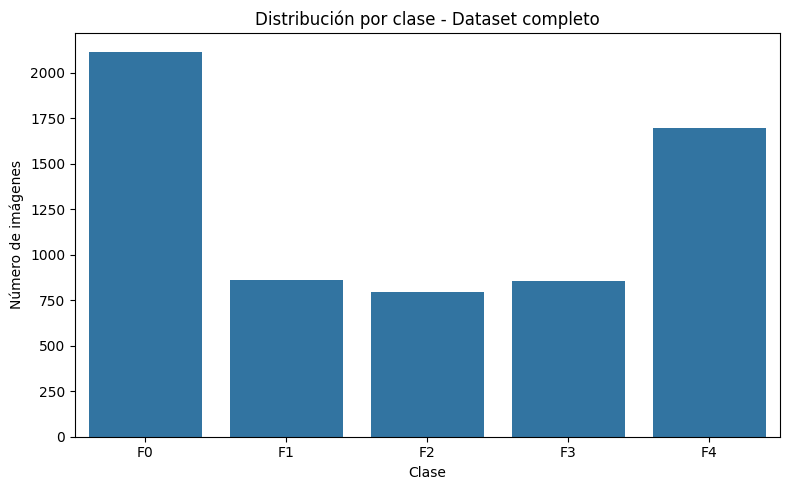

Número total de imágenes: 6323
Entrenamiento: 5058 | Prueba: 1265


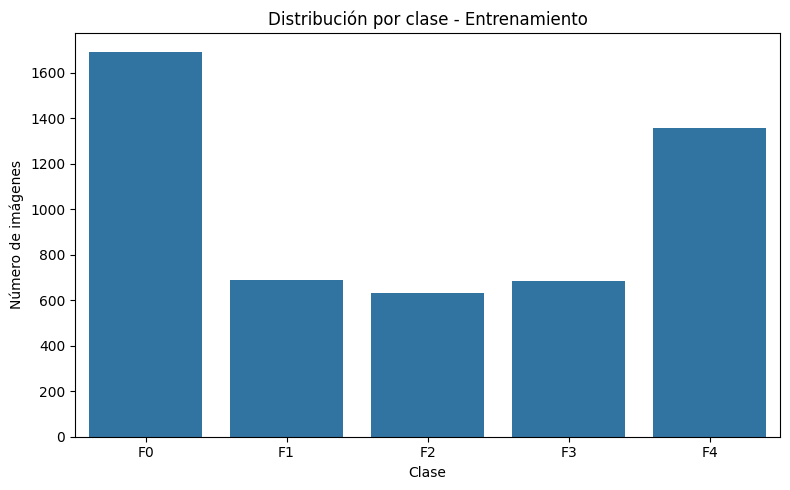

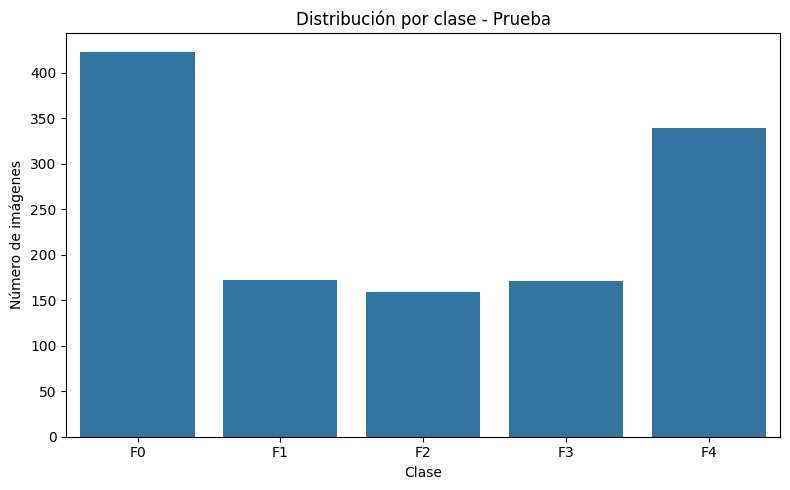

In [9]:
# ===================================
# Preparación de los datos
# ===================================
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image


ruta_dataset = './liver_dataset/Dataset/Dataset/'
clases = ['F0', 'F1', 'F2', 'F3', 'F4']

rutas_imagenes = []
etiquetas = []

for clase in clases:
    carpeta_clase = os.path.join(ruta_dataset, clase)
    for archivo in os.listdir(carpeta_clase):
        rutas_imagenes.append(os.path.join(carpeta_clase, archivo))
        etiquetas.append(clase)


print(f"Número total de imágenes: {len(df_imagenes)}")

conteo_total = df_imagenes['Etiqueta'].value_counts().sort_index()
print("\nNúmero de imágenes por clase:")
for clase, cantidad in conteo_total.items():
    print(f"{clase}: {cantidad}")


conteo_total = df_imagenes['Etiqueta'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=conteo_total.index, y=conteo_total.values)
plt.title("Distribución por clase - Dataset completo")
plt.xlabel('Clase')
plt.ylabel('Número de imágenes')
plt.tight_layout()
plt.show()


df_imagenes = pd.DataFrame({'Ruta': rutas_imagenes, 'Etiqueta': etiquetas})
df_imagenes.to_csv('imagenes_etiquetadas.csv', index=False)


df_train, df_test = train_test_split(
    df_imagenes,
    test_size=0.2,
    stratify=df_imagenes['Etiqueta'],
    random_state=42
)

print(f"Número total de imágenes: {len(df_imagenes)}")
print(f"Entrenamiento: {len(df_train)} | Prueba: {len(df_test)}")

def graficar_distribucion(dataset, titulo):
    conteo = dataset['Etiqueta'].value_counts().sort_index()
    plt.figure(figsize=(8, 5))
    sns.barplot(x=conteo.index, y=conteo.values)
    plt.title(titulo)
    plt.xlabel('Clase')
    plt.ylabel('Número de imágenes')
    plt.tight_layout()
    plt.show()

graficar_distribucion(df_train, "Distribución por clase - Entrenamiento")
graficar_distribucion(df_test, "Distribución por clase - Prueba")

In [5]:
# ===================================
# Carga de imágenes y etiquetas
# ===================================
def cargar_imagenes_y_etiquetas(dataframe, tamano=(224, 224)):
    imagenes = []
    etiquetas = []
    clases_unicas = sorted(dataframe['Etiqueta'].unique())
    indice_clases = {nombre: i for i, nombre in enumerate(clases_unicas)}

    for _, fila in dataframe.iterrows():
        img = Image.open(fila['Ruta'])
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img = img.resize(tamano)
        imagenes.append(np.array(img))
        etiquetas.append(indice_clases[fila['Etiqueta']])

    return np.array(imagenes), np.array(etiquetas), indice_clases

tamano_imagen = (224, 224)
X_train, y_train, indice_clases = cargar_imagenes_y_etiquetas(df_train, tamano_imagen)
X_val, y_val, _ = cargar_imagenes_y_etiquetas(df_test, tamano_imagen)

print(f"Clases: {indice_clases}")
print(f"Número de clases: {len(indice_clases)}")

Clases: {'F0': 0, 'F1': 1, 'F2': 2, 'F3': 3, 'F4': 4}
Número de clases: 5


## 2: Entrenamiento Modelo Resnet


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 975ms/step - accuracy: 0.3981 - loss: 1.4068 - val_accuracy: 0.5178 - val_loss: 1.1460
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.6302 - loss: 0.9159 - val_accuracy: 0.6174 - val_loss: 0.9250
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.7072 - loss: 0.7312 - val_accuracy: 0.6791 - val_loss: 0.7771
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.7674 - loss: 0.6190 - val_accuracy: 0.7241 - val_loss: 0.6546
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.8159 - loss: 0.5121 - val_accuracy: 0.7874 - val_loss: 0.5471
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8673 - loss: 0.4116 - val_accuracy: 0.8142 - val_loss: 0.4620
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9007 - loss: 0.3546 - val_accuracy: 0.8545 - val_loss: 0.3844
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9207 - loss: 0.2867 - val_accuracy: 0.8822 -

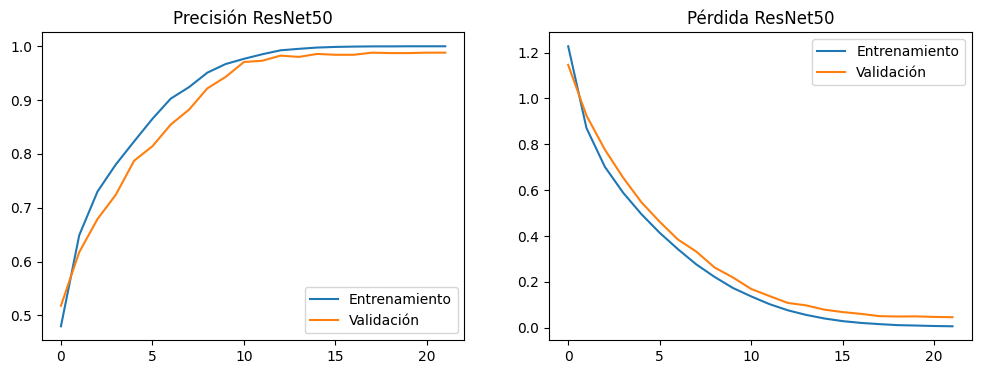

In [10]:
# ===================================
# Modelo ResNet50 con Fine Tuning
# ===================================
from tensorflow.keras.applications import ResNet50
from PIL import Image
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False
for capa in base_resnet.layers[-20:]:
    capa.trainable = True

modelo_resnet = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='sigmoid')
])

modelo_resnet.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)


historial_resnet = modelo_resnet.fit(
    X_train, y_train,
    epochs=50,
    batch_size=200,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

# Curvas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historial_resnet.history['accuracy'], label='Entrenamiento')
plt.plot(historial_resnet.history['val_accuracy'], label='Validación')
plt.title("Precisión ResNet50")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial_resnet.history['loss'], label='Entrenamiento')
plt.plot(historial_resnet.history['val_loss'], label='Validación')
plt.title("Pérdida ResNet50")
plt.legend()
plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


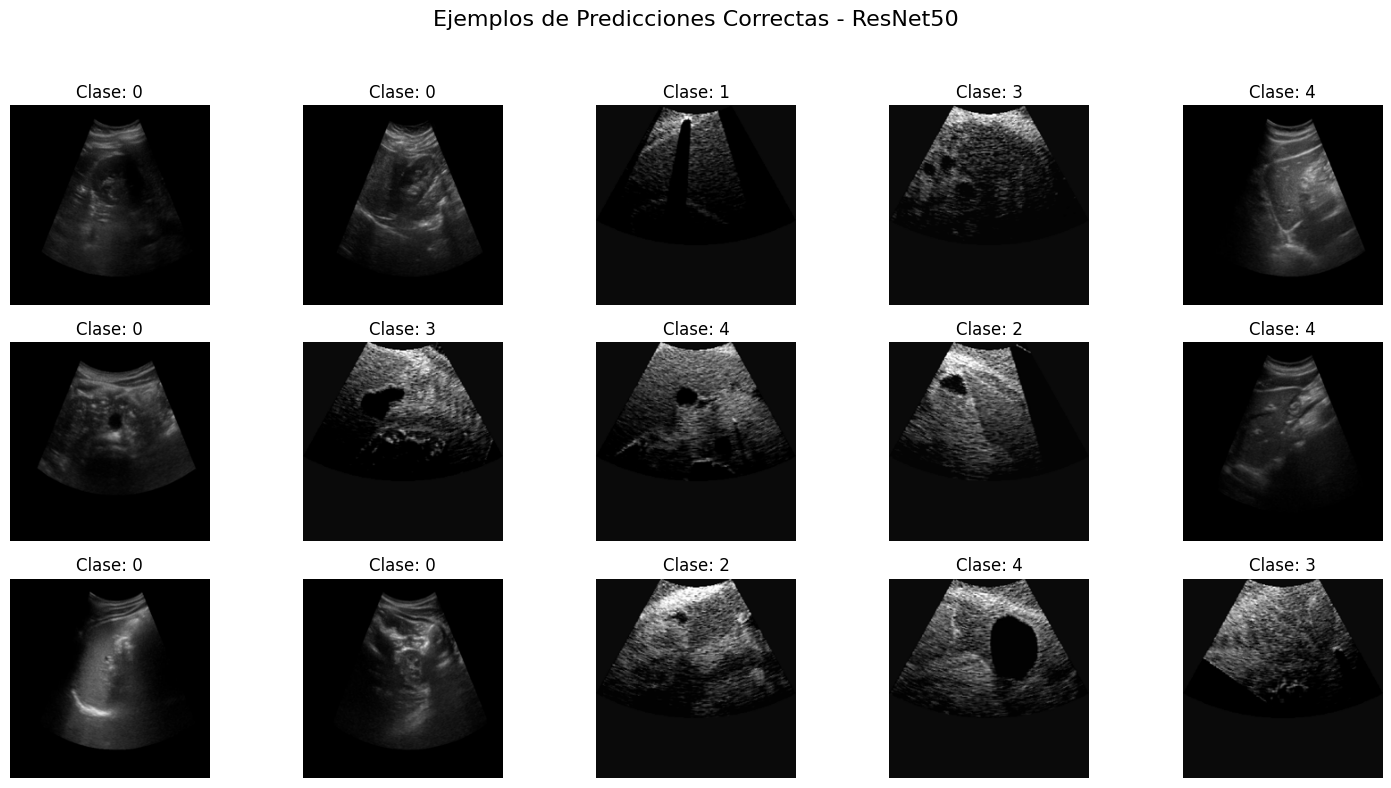

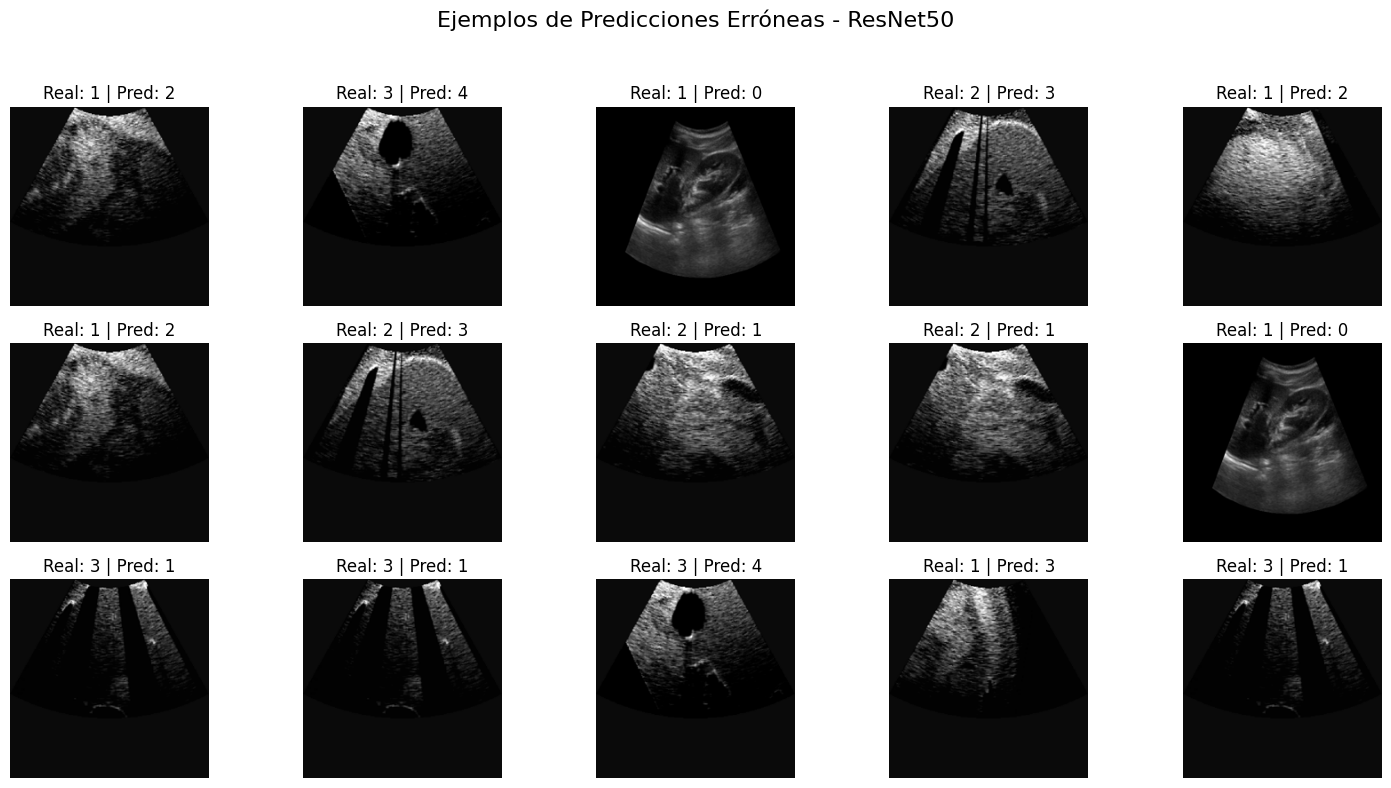

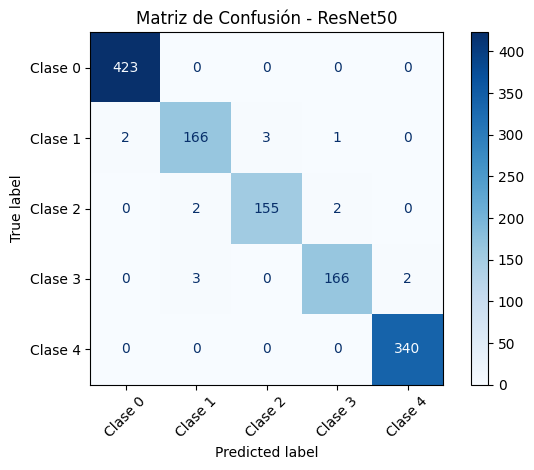

Reporte de clasificación - ResNet50
              precision    recall  f1-score   support

     Clase 0       1.00      1.00      1.00       423
     Clase 1       0.97      0.97      0.97       172
     Clase 2       0.98      0.97      0.98       159
     Clase 3       0.98      0.97      0.98       171
     Clase 4       0.99      1.00      1.00       340

    accuracy                           0.99      1265
   macro avg       0.98      0.98      0.98      1265
weighted avg       0.99      0.99      0.99      1265



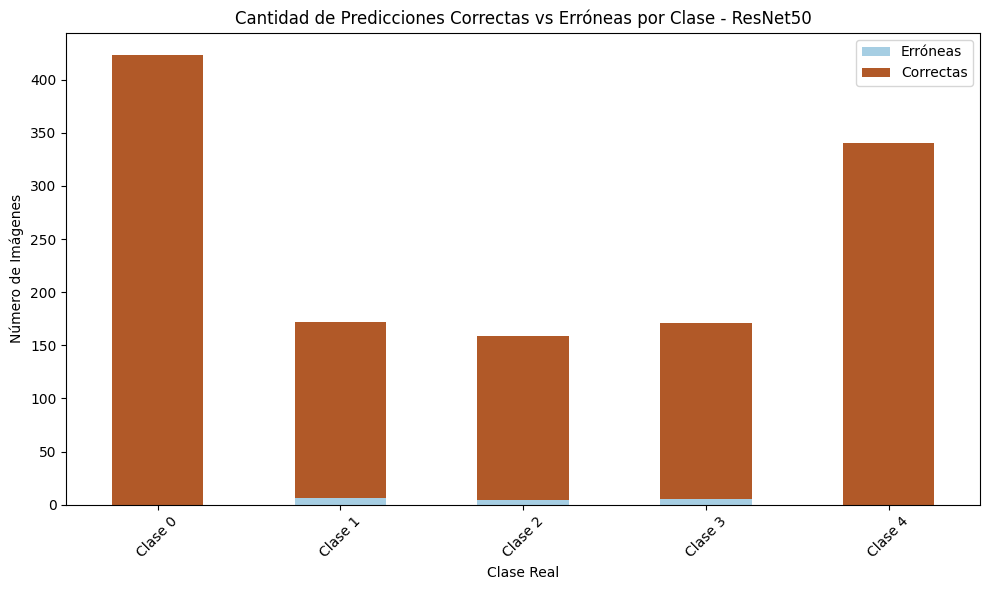

In [12]:
# ===================================
# Visualización de predicciones correctas y errores - ResNet50
# ===================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Obtener predicciones del modelo
y_pred_resnet_probs = modelo_resnet.predict(X_val)
y_pred_resnet_labels = np.argmax(y_pred_resnet_probs, axis=1)

# Identificar predicciones correctas y erróneas
indices_correctos = np.where(y_pred_resnet_labels == y_val)[0]
indices_erroneos = np.where(y_pred_resnet_labels != y_val)[0]

# Visualizar 15 predicciones correctas
plt.figure(figsize=(15, 8))
plt.suptitle("Ejemplos de Predicciones Correctas - ResNet50", fontsize=16)
muestras_correctas = np.random.choice(indices_correctos, min(15, len(indices_correctos)), replace=False)
for i, idx in enumerate(muestras_correctas):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_val[idx])
    plt.axis('off')
    plt.title(f"Clase: {y_val[idx]}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Visualizar 15 predicciones erróneas
plt.figure(figsize=(15, 8))
plt.suptitle("Ejemplos de Predicciones Erróneas - ResNet50", fontsize=16)
muestras_erroneas = np.random.choice(indices_erroneos, min(15, len(indices_erroneos)), replace=False)
for i, idx in enumerate(muestras_erroneas):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_val[idx])
    plt.axis('off')
    plt.title(f"Real: {y_val[idx]} | Pred: {y_pred_resnet_labels[idx]}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Matriz de confusión
cm_resnet = confusion_matrix(y_val, y_pred_resnet_labels)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=[f"Clase {i}" for i in range(5)])
disp_resnet.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - ResNet50")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("Reporte de clasificación - ResNet50")
print(classification_report(y_val, y_pred_resnet_labels, target_names=[f"Clase {i}" for i in range(5)]))

# ===================================
# Gráfico de errores por clase
# ===================================
import pandas as pd
import seaborn as sns

df_errores = pd.DataFrame({
    'Real': y_val,
    'Predicho': y_pred_resnet_labels
})
df_errores['Correcto'] = df_errores['Real'] == df_errores['Predicho']

conteo_errores = df_errores.groupby(['Real', 'Correcto']).size().unstack(fill_value=0)
conteo_errores.index = [f"Clase {i}" for i in conteo_errores.index]

# Gráfico de barras de aciertos vs errores por clase
conteo_errores.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Paired')
plt.title("Cantidad de Predicciones Correctas vs Erróneas por Clase - ResNet50")
plt.ylabel("Número de Imágenes")
plt.xlabel("Clase Real")
plt.xticks(rotation=45)
plt.legend(["Erróneas", "Correctas"])
plt.tight_layout()
plt.show()


## 3: Entrenamiento Modelo VGG16


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 595ms/step - accuracy: 0.4505 - loss: 3.1085 - val_accuracy: 0.7217 - val_loss: 0.7732
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.6873 - loss: 0.8709 - val_accuracy: 0.8245 - val_loss: 0.4668
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.7919 - loss: 0.5496 - val_accuracy: 0.8822 - val_loss: 0.3392
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.8536 - loss: 0.3745 - val_accuracy: 0.9518 - val_loss: 0.2062
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9226 - loss: 0.2335 - val_accuracy: 0.9581 - val_loss: 0.1548
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9510 - loss: 0.1706 - val_accuracy: 0.9644 - val_loss: 0.1393
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9619 - loss: 0.1304 - val_accuracy: 0.9739 - val_loss: 0.1065
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step 

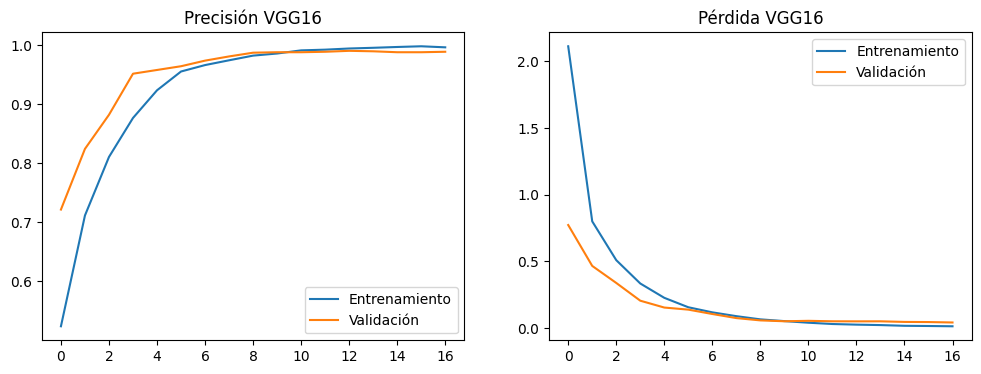

In [13]:
# ===================================
# Modelo VGG16 con Fine Tuning
# ===================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_vgg.trainable = False
for capa in base_vgg.layers[-4:]:
    capa.trainable = True

modelo_vgg = models.Sequential([
    base_vgg,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

modelo_vgg.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

historial_vgg = modelo_vgg.fit(
    X_train, y_train,
    epochs=50,
    batch_size=200,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

# Visualización del entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historial_vgg.history['accuracy'], label='Entrenamiento')
plt.plot(historial_vgg.history['val_accuracy'], label='Validación')
plt.title("Precisión VGG16")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial_vgg.history['loss'], label='Entrenamiento')
plt.plot(historial_vgg.history['val_loss'], label='Validación')
plt.title("Pérdida VGG16")
plt.legend()
plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step


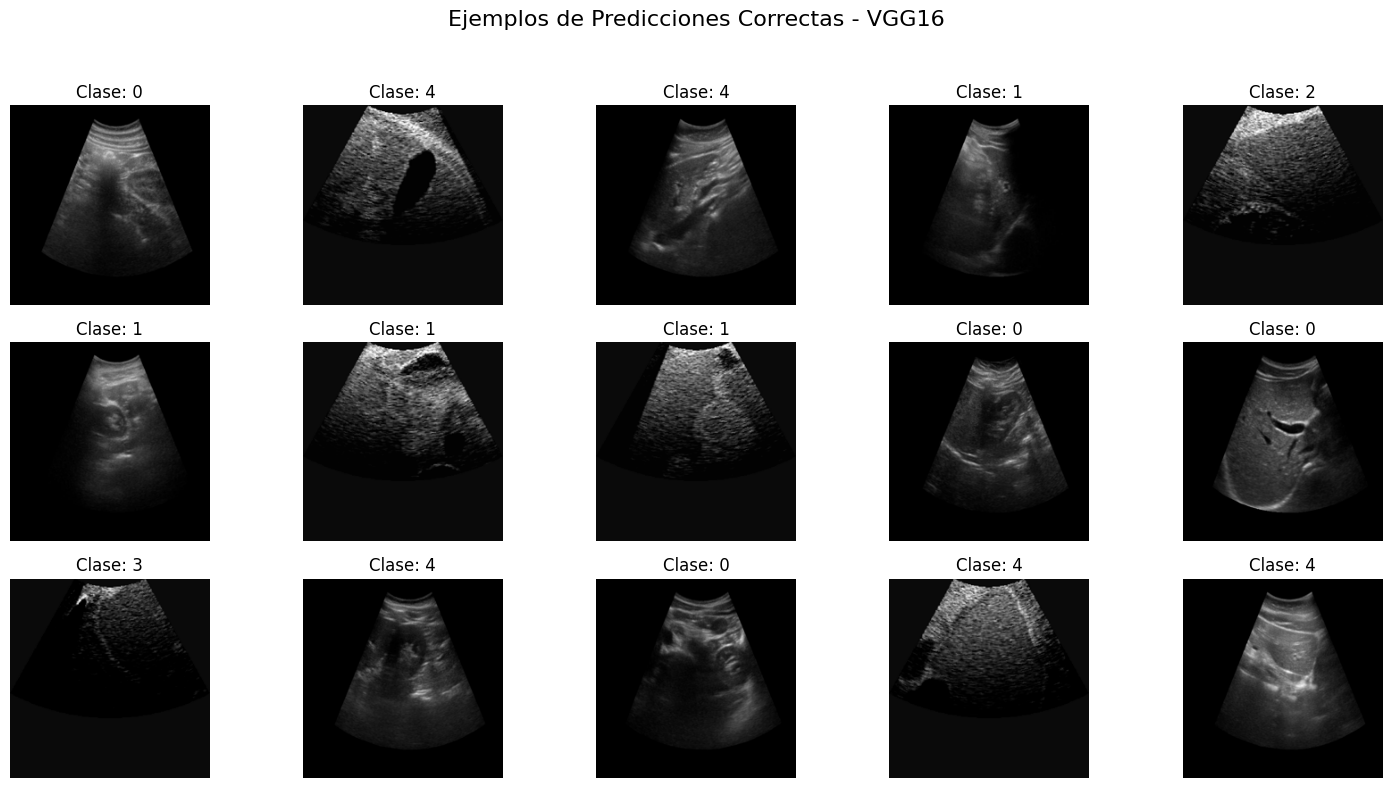

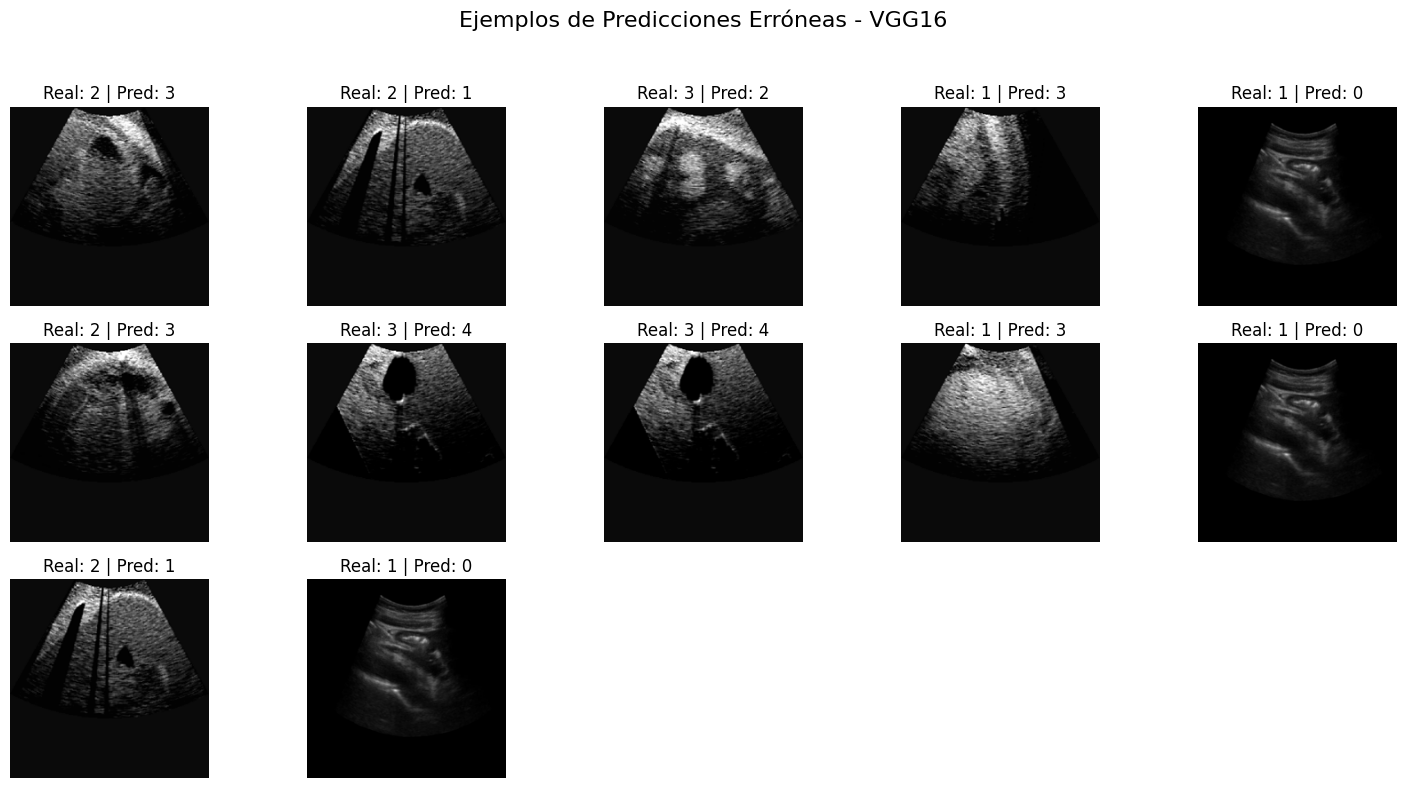

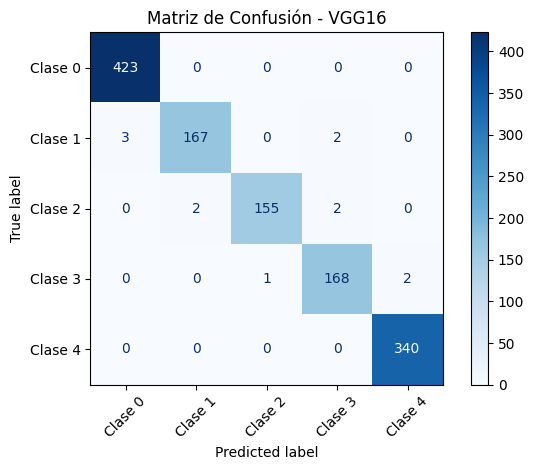

Reporte de clasificación - VGG16
              precision    recall  f1-score   support

     Clase 0       0.99      1.00      1.00       423
     Clase 1       0.99      0.97      0.98       172
     Clase 2       0.99      0.97      0.98       159
     Clase 3       0.98      0.98      0.98       171
     Clase 4       0.99      1.00      1.00       340

    accuracy                           0.99      1265
   macro avg       0.99      0.99      0.99      1265
weighted avg       0.99      0.99      0.99      1265



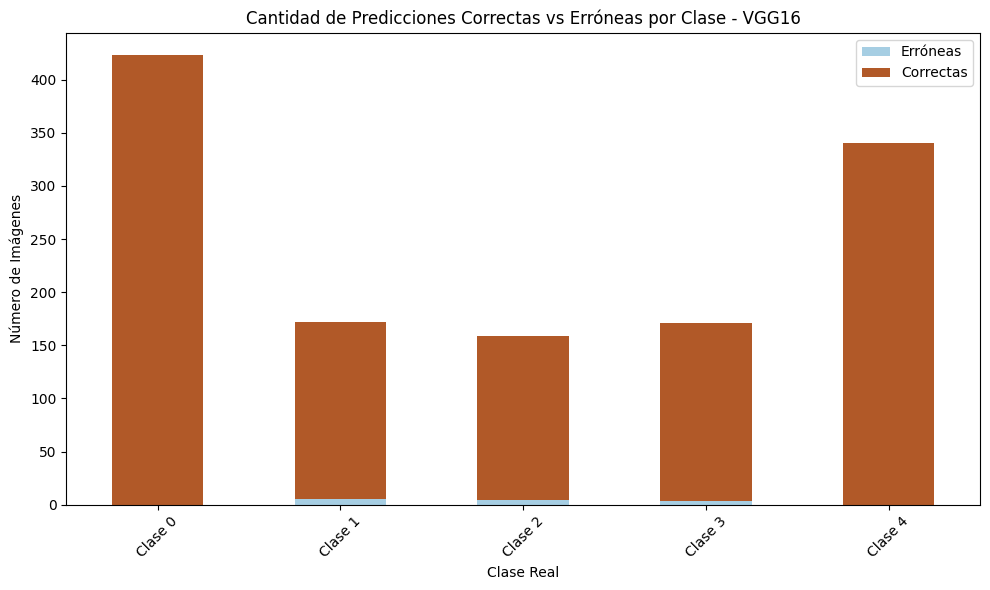

In [14]:
# ===================================
# Visualización de predicciones correctas y errores - VGG16
# ===================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Obtener predicciones del modelo VGG16
y_pred_vgg_probs = modelo_vgg.predict(X_val)
y_pred_vgg_labels = np.argmax(y_pred_vgg_probs, axis=1)

# Identificar predicciones correctas y erróneas
indices_correctos_vgg = np.where(y_pred_vgg_labels == y_val)[0]
indices_erroneos_vgg = np.where(y_pred_vgg_labels != y_val)[0]

# Visualizar 15 predicciones correctas
plt.figure(figsize=(15, 8))
plt.suptitle("Ejemplos de Predicciones Correctas - VGG16", fontsize=16)
muestras_correctas_vgg = np.random.choice(indices_correctos_vgg, min(15, len(indices_correctos_vgg)), replace=False)
for i, idx in enumerate(muestras_correctas_vgg):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_val[idx])
    plt.axis('off')
    plt.title(f"Clase: {y_val[idx]}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Visualizar 15 predicciones erróneas
plt.figure(figsize=(15, 8))
plt.suptitle("Ejemplos de Predicciones Erróneas - VGG16", fontsize=16)
muestras_erroneas_vgg = np.random.choice(indices_erroneos_vgg, min(15, len(indices_erroneos_vgg)), replace=False)
for i, idx in enumerate(muestras_erroneas_vgg):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_val[idx])
    plt.axis('off')
    plt.title(f"Real: {y_val[idx]} | Pred: {y_pred_vgg_labels[idx]}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Matriz de confusión - VGG16
cm_vgg = confusion_matrix(y_val, y_pred_vgg_labels)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=[f"Clase {i}" for i in range(5)])
disp_vgg.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - VGG16")
plt.tight_layout()
plt.show()

# Reporte de clasificación - VGG16
print("Reporte de clasificación - VGG16")
print(classification_report(y_val, y_pred_vgg_labels, target_names=[f"Clase {i}" for i in range(5)]))

# ===================================
# Gráfico de errores por clase - VGG16
# ===================================
import pandas as pd
import seaborn as sns

df_errores_vgg = pd.DataFrame({
    'Real': y_val,
    'Predicho': y_pred_vgg_labels
})
df_errores_vgg['Correcto'] = df_errores_vgg['Real'] == df_errores_vgg['Predicho']

conteo_errores_vgg = df_errores_vgg.groupby(['Real', 'Correcto']).size().unstack(fill_value=0)
conteo_errores_vgg.index = [f"Clase {i}" for i in conteo_errores_vgg.index]

# Gráfico de barras
conteo_errores_vgg.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Paired')
plt.title("Cantidad de Predicciones Correctas vs Erróneas por Clase - VGG16")
plt.ylabel("Número de Imágenes")
plt.xlabel("Clase Real")
plt.xticks(rotation=45)
plt.legend(["Erróneas", "Correctas"])
plt.tight_layout()
plt.show()
